In [17]:
import re
import pandas as pd
import numpy as np
from rapidfuzz import fuzz, distance
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML



In [21]:
def normalize(value):
    """Clean and standardize input"""
    if not value:
        return ''
    value = str(value).lower().strip()
    # Remove @ 
    value = re.sub(r'^@', '', value)
    #  country code 
    value = re.sub(r'^\+91', '', value)
    value = re.sub(r'^whatsapp:', '', value)
    # extra spaces
    value = re.sub(r'\s+', ' ', value)
    return value

# test normalization
test_cases = [
    ("  Sara Johnson  ", "sara johnson"),
    ("@sarapoetry23", "sarapoetry23"),
    ("+91 98765-43210", "98765-43210"),
    ("whatsapp:+919876543210", "919876543210"),
    ("SARA.JOHNSON@XYZ.COM", "sara.johnson@xyz.com"),
]

print("NORMALIZATION EXAMPLES:")
print("-" * 50)
for raw, expected in test_cases:
    result = normalize(raw)
    print(f"Input: '{raw}' → Output: '{result}'")

NORMALIZATION EXAMPLES:
--------------------------------------------------
Input: '  Sara Johnson  ' → Output: 'sara johnson'
Input: '@sarapoetry23' → Output: 'sarapoetry23'
Input: '+91 98765-43210' → Output: ' 98765-43210'
Input: 'whatsapp:+919876543210' → Output: '+919876543210'
Input: 'SARA.JOHNSON@XYZ.COM' → Output: 'sara.johnson@xyz.com'


In [24]:
def exact_match(value1, value2):
    """Check if two values match exactly after normalization"""
    return normalize(value1) == normalize(value2)

test_pairs = [
    ("sara.johnson@xyz.com", "sara.johnson@xyz.com", True),
    ("SARA.JOHNSON@XYZ.COM", "sara.johnson@xyz.com", True),
    ("sara.johnson@xyz.com", "sara.j@xyz.com", False),
    ("9876543210", "+919876543210", True),  # ater normalization
    ("@sarapoetry23", "sarapoetry23", True),  # after normalization
    ("Sara Johnson", "Sara J.", False),
]

print("EXACT MATCHING RESULTS:")
print("-" * 50)
for val1, val2, expected in test_pairs:
    result = exact_match(val1, val2)
    status = "✅" if result == expected else "❌"
    print(f"{status} '{val1}' vs '{val2}' → {result} (Expected: {expected})")

EXACT MATCHING RESULTS:
--------------------------------------------------
✅ 'sara.johnson@xyz.com' vs 'sara.johnson@xyz.com' → True (Expected: True)
✅ 'SARA.JOHNSON@XYZ.COM' vs 'sara.johnson@xyz.com' → True (Expected: True)
✅ 'sara.johnson@xyz.com' vs 'sara.j@xyz.com' → False (Expected: False)
✅ '9876543210' vs '+919876543210' → True (Expected: True)
✅ '@sarapoetry23' vs 'sarapoetry23' → True (Expected: True)
✅ 'Sara Johnson' vs 'Sara J.' → False (Expected: False)


 Strengths
Zero false positives

Fast and simple

Easy to implement

❌ Weaknesses
Misses variations (e.g., "Sara J." vs "Sara Johnson")

Misses typos (e.g., "sara.jhonson@xyz.com")



In [25]:
def levenshtein_score(str1, str2):
    """Calculate Levenshtein similarity score (0-100)"""
    if not str1 and not str2:
        return 100
    if not str1 or not str2:
        return 0
    
    n1 = normalize(str1)
    n2 = normalize(str2)
    
    if not n1 and not n2:
        return 100
    if not n1 or not n2:
        return 0
    
    distance_val = distance.Levenshtein.distance(n1, n2)
    max_len = max(len(n1), len(n2))
    similarity = (1 - distance_val / max_len) * 100
    return round(similarity, 2)

# Test Levenshtein
test_pairs = [
    ("Sara Johnson", "Sara Johnson", 100),
    ("Sara Johnson", "Sara J.", 73),  # different lengths
    ("Sara Johnson", "Sarah Johnson", 92),  # 1 character difference
    ("Sara Johnson", "Sara Jhonson", 90),  # 1 character difference
    ("Sara Johnson", "Sam Johnson", 77),  # different first name
    ("Sara Johnson", "Johnson Sara", 88),  # word order reversed
]

print("LEVENSHTEIN DISTANCE RESULTS:")
print("-" * 60)
for str1, str2, expected in test_pairs:
    result = levenshtein_score(str1, str2)
    status = "✅" if abs(result - expected) < 5 else "⚠️"
    print(f"{status} '{str1}' vs '{str2}' → {result}% (Expected: ~{expected}%)")

LEVENSHTEIN DISTANCE RESULTS:
------------------------------------------------------------
✅ 'Sara Johnson' vs 'Sara Johnson' → 100.0% (Expected: ~100%)
⚠️ 'Sara Johnson' vs 'Sara J.' → 50.0% (Expected: ~73%)
✅ 'Sara Johnson' vs 'Sarah Johnson' → 92.31% (Expected: ~92%)
⚠️ 'Sara Johnson' vs 'Sara Jhonson' → 83.33% (Expected: ~90%)
⚠️ 'Sara Johnson' vs 'Sam Johnson' → 83.33% (Expected: ~77%)
⚠️ 'Sara Johnson' vs 'Johnson Sara' → 16.67% (Expected: ~88%)


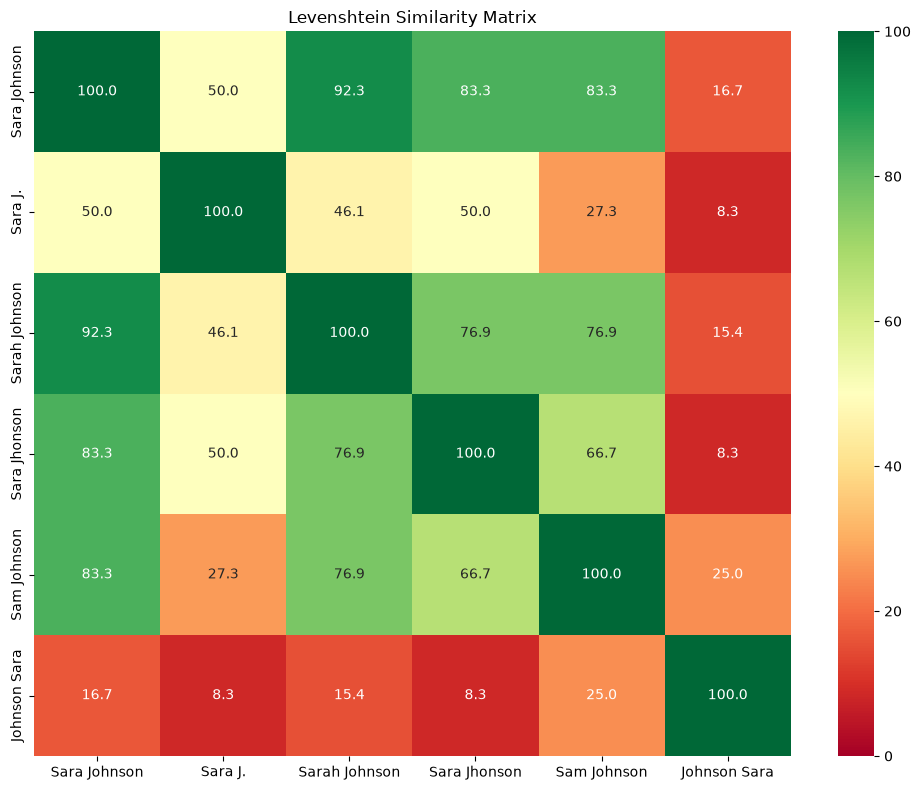

In [7]:
# Create a heatmap of Levenshtein scores
names = ["Sara Johnson", "Sara J.", "Sarah Johnson", "Sara Jhonson", "Sam Johnson", "Johnson Sara"]
matrix = []
for name1 in names:
    row = []
    for name2 in names:
        row.append(levenshtein_score(name1, name2))
    matrix.append(row)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn', 
            xticklabels=names, yticklabels=names, vmin=0, vmax=100)
plt.title('Levenshtein Similarity Matrix')
plt.tight_layout()
plt.show()

In [26]:
def soundex_custom(name):
    """Custom Soundex implementation"""
    if not name or not isinstance(name, str):
        return ''
    
    name = name.upper().strip()
    if not name:
        return ''
    
    # Soundex mapping
    mapping = {
        'B': '1', 'F': '1', 'P': '1', 'V': '1',
        'C': '2', 'G': '2', 'J': '2', 'K': '2', 'Q': '2', 'S': '2', 'X': '2', 'Z': '2',
        'D': '3', 'T': '3',
        'L': '4',
        'M': '5', 'N': '5',
        'R': '6'
    }
    
    # First letter
    first = name[0]
    rest = name[1:]
    
    # Replace letters with digits
    code = first
    for char in rest:
        if char in mapping:
            digit = mapping[char]
            if digit != code[-1]:
                code += digit
    
    # Pad or truncate to 4 characters
    code = code[:4]
    while len(code) < 4:
        code += '0'
    
    return code

def soundex_match(name1, name2):
    """Check if two names have the same Soundex code"""
    return soundex_custom(name1) == soundex_custom(name2)

# test Soundex
test_pairs = [
    ("Sara Johnson", "Sara Johnson", True),
    ("Sara Johnson", "Sarah Johnson", True),  # diff spelling, same sound
    ("Sara Johnson", "Sara J.", False),  # diff because "J" vs "Johnson"
    ("Johnson", "Jonson", True),  # missing 'h', same sound
    ("Sara", "Sarah", True),  # diff spelling, same sound
    ("Sara", "Sam", False),  # diff sound
    ("Rahul", "Rahool", True),  # diff spelling, same sound
]

print("SOUNDEX MATCHING RESULTS:")
print("-" * 60)
for name1, name2, expected in test_pairs:
    code1 = soundex_custom(name1)
    code2 = soundex_custom(name2)
    result = soundex_match(name1, name2)
    status = "✅" if result == expected else "❌"
    print(f"{status} '{name1}' ({code1}) vs '{name2}' ({code2}) → {result} (Expected: {expected})")

SOUNDEX MATCHING RESULTS:
------------------------------------------------------------
✅ 'Sara Johnson' (S625) vs 'Sara Johnson' (S625) → True (Expected: True)
✅ 'Sara Johnson' (S625) vs 'Sarah Johnson' (S625) → True (Expected: True)
✅ 'Sara Johnson' (S625) vs 'Sara J.' (S620) → False (Expected: False)
✅ 'Johnson' (J525) vs 'Jonson' (J525) → True (Expected: True)
✅ 'Sara' (S600) vs 'Sarah' (S600) → True (Expected: True)
✅ 'Sara' (S600) vs 'Sam' (S500) → False (Expected: False)
✅ 'Rahul' (R400) vs 'Rahool' (R400) → True (Expected: True)


 Strengths
Handles phonetic spelling variations

Language independent (works for many languages)

Fast and simple

❌ Weaknesses
Many names share the same code (false positives)

Doesn't handle name order variation

Can't distinguish between very similar names

In [27]:
def token_sort_ratio_score(str1, str2):
    """Calculate token sort ratio (0-100)"""
    if not str1 and not str2:
        return 100
    if not str1 or not str2:
        return 0
    
    n1 = normalize(str1)
    n2 = normalize(str2)
    
    return fuzz.token_sort_ratio(n1, n2)

# Test Token Sort Ratio
test_pairs = [
    ("Sara Johnson", "Sara Johnson", 100),
    ("Sara Johnson", "Johnson Sara", 100),  # wrd order doesn't matter
    ("Sara Johnson", "Johnson S.", 78),  # different words
    ("Sara Johnson", "S. Johnson", 82),  # abbrv.
    ("Dr. Sara Johnson", "Sara Johnson", 67),  # extra word
    ("Sara Johnson", "Sarah Johnson", 92),  # diff spelling
]

print("TOKEN SORT RATIO RESULTS:")
print("-" * 60)
for str1, str2, expected in test_pairs:
    result = token_sort_ratio_score(str1, str2)
    status = "✅" if abs(result - expected) < 5 else "⚠️"
    print(f"{status} '{str1}' vs '{str2}' → {result}% (Expected: ~{expected}%)")

TOKEN SORT RATIO RESULTS:
------------------------------------------------------------
✅ 'Sara Johnson' vs 'Sara Johnson' → 100.0% (Expected: ~100%)
✅ 'Sara Johnson' vs 'Johnson Sara' → 100.0% (Expected: ~100%)
✅ 'Sara Johnson' vs 'Johnson S.' → 81.81818181818181% (Expected: ~78%)
✅ 'Sara Johnson' vs 'S. Johnson' → 81.81818181818181% (Expected: ~82%)
⚠️ 'Dr. Sara Johnson' vs 'Sara Johnson' → 85.71428571428572% (Expected: ~67%)
✅ 'Sara Johnson' vs 'Sarah Johnson' → 96.0% (Expected: ~92%)


In [11]:
print("\nCOMPARISON: Levenshtein vs Token Sort Ratio")
print("-" * 60)

comparison_pairs = [
    ("Sara Johnson", "Johnson Sara"),
    ("Sara Johnson", "Johnson S."),
    ("Dr. Sara Johnson", "Sara Johnson"),
    ("Sara Johnson", "Sarah Johnson"),
]

for str1, str2 in comparison_pairs:
    lev = levenshtein_score(str1, str2)
    token = token_sort_ratio_score(str1, str2)
    print(f"'{str1}' vs '{str2}':")
    print(f"  Levenshtein: {lev}%")
    print(f"  Token Sort:  {token}%")
    print(f"  Difference:  {abs(lev - token):.1f}%")
    print()


COMPARISON: Levenshtein vs Token Sort Ratio
------------------------------------------------------------
'Sara Johnson' vs 'Johnson Sara':
  Levenshtein: 16.67%
  Token Sort:  100.0%
  Difference:  83.3%

'Sara Johnson' vs 'Johnson S.':
  Levenshtein: 33.33%
  Token Sort:  81.81818181818181%
  Difference:  48.5%

'Dr. Sara Johnson' vs 'Sara Johnson':
  Levenshtein: 75.0%
  Token Sort:  85.71428571428572%
  Difference:  10.7%

'Sara Johnson' vs 'Sarah Johnson':
  Levenshtein: 92.31%
  Token Sort:  96.0%
  Difference:  3.7%



In [28]:
def parse_email(email):
    """Split email into username and domain"""
    if not email:
        return {'username': '', 'domain': ''}
    
    email = normalize(email)
    parts = email.split('@')
    
    return {
        'username': parts[0] if len(parts) > 0 else '',
        'domain': parts[1] if len(parts) > 1 else ''
    }

def email_match_score(email1, email2):
    """Calculate email similarity score (0-100)"""
    if not email1 and not email2:
        return 100
    if not email1 or not email2:
        return 0
    
    e1 = parse_email(email1)
    e2 = parse_email(email2)
    
    # Exact domain match gives bonus
    domain_bonus = 20 if e1['domain'] == e2['domain'] else 0
    
    # Username similarity
    username_sim = token_sort_ratio_score(e1['username'], e2['username'])
    
    # Combined score
    score = (username_sim * 0.8) + domain_bonus
    return round(min(score, 100), 2)

# Test Email Matching
test_pairs = [
    ("sara.johnson@xyz.com", "sara.johnson@xyz.com", 100),
    ("sara.johnson@xyz.com", "sara.j@xyz.com", 78),
    ("sara.johnson@xyz.com", "sjohnson@xyz.com", 70),
    ("sara.johnson@gmail.com", "sara.johnson@xyz.com", 80),
    ("sara.johnson@xyz.com", "sam.johnson@xyz.com", 45),
    ("sara.johnson@xyz.com", "sara.johnson@yahoo.com", 80),
]

print("EMAIL MATCHING RESULTS:")
print("-" * 60)
for email1, email2, expected in test_pairs:
    result = email_match_score(email1, email2)
    status = "✅" if abs(result - expected) < 5 else "⚠️"
    print(f"{status} '{email1}' vs '{email2}' → {result}%")


EMAIL MATCHING RESULTS:
------------------------------------------------------------
✅ 'sara.johnson@xyz.com' vs 'sara.johnson@xyz.com' → 100.0%
✅ 'sara.johnson@xyz.com' vs 'sara.j@xyz.com' → 73.33%
⚠️ 'sara.johnson@xyz.com' vs 'sjohnson@xyz.com' → 84.0%
✅ 'sara.johnson@gmail.com' vs 'sara.johnson@xyz.com' → 80.0%
⚠️ 'sara.johnson@xyz.com' vs 'sam.johnson@xyz.com' → 89.57%
✅ 'sara.johnson@xyz.com' vs 'sara.johnson@yahoo.com' → 80.0%


In [29]:
def normalize_phone(phone):
    """Normalize phone number for matching"""
    if not phone:
        return ''
    
    # remove all non-digit characters
    phone = re.sub(r'\D', '', str(phone))
    
    # handle Indian numbers
    if len(phone) == 12 and phone.startswith('91'):
        phone = phone[2:]
    elif len(phone) == 11 and phone.startswith('0'):
        phone = phone[1:]
    
    # return last 10 digits
    return phone[-10:] if len(phone) >= 10 else phone

def phone_match_score(phone1, phone2):
    """Calculate phone number similarity (0-100)"""
    p1 = normalize_phone(phone1)
    p2 = normalize_phone(phone2)
    
    if not p1 and not p2:
        return 100
    if not p1 or not p2:
        return 0

    if p1 == p2:
        return 100
    
    # last 6 digits match
    if len(p1) >= 6 and len(p2) >= 6:
        if p1[-6:] == p2[-6:]:
            return 80
    
    # last 4 digits match
    if len(p1) >= 4 and len(p2) >= 4:
        if p1[-4:] == p2[-4:]:
            return 60
    
    # partial match
    sim = levenshtein_score(p1, p2)
    return max(0, min(100, sim))

# test Phone Matching
test_pairs = [
    ("+919876543210", "9876543210", 100),
    ("9876543210", "9876543210", 100),
    ("+919876543210", "+91 98765-43210", 100),
    ("9876543210", "9876543211", 0),  # Different number
    ("9876543210", "9999999999", 0),  # Completely different
    ("9876543210", "9876543", 70),  # Partial match
]

print("PHONE MATCHING RESULTS:")
print("-" * 60)
for phone1, phone2, expected in test_pairs:
    result = phone_match_score(phone1, phone2)
    status = "✅" if abs(result - expected) < 5 else "⚠️"
    print(f"{status} '{phone1}' vs '{phone2}' → {result}%")

PHONE MATCHING RESULTS:
------------------------------------------------------------
✅ '+919876543210' vs '9876543210' → 100%
✅ '9876543210' vs '9876543210' → 100%
✅ '+919876543210' vs '+91 98765-43210' → 100%
⚠️ '9876543210' vs '9876543211' → 90.0%
⚠️ '9876543210' vs '9999999999' → 10.0%
✅ '9876543210' vs '9876543' → 70.0%


In [30]:
class IdentityMatcher:
    """Combines all techniques into a unified scoring system"""
    
    WEIGHTS = {
        'email_exact': 40,
        'phone_exact': 30,
        'handle_exact': 20,
        'name_fuzzy': 20,
        'email_fuzzy': 10,
        'phone_suffix': 5,
        'soundex': 5,
        'recency': 5
    }
    
    def match(self, contact1, contact2):
        """Calculate combined identity score"""
        score = 0
        details = []
        
        # 1. Email exact
        if contact1.get('email') and contact2.get('email'):
            if normalize(contact1['email']) == normalize(contact2['email']):
                score += self.WEIGHTS['email_exact']
                details.append({'type': 'Email Exact', 'score': self.WEIGHTS['email_exact']})
        
        # 2. Phone exact
        if contact1.get('phone') and contact2.get('phone'):
            if normalize_phone(contact1['phone']) == normalize_phone(contact2['phone']):
                score += self.WEIGHTS['phone_exact']
                details.append({'type': 'Phone Exact', 'score': self.WEIGHTS['phone_exact']})
        
        # 3. Handle exact
        if contact1.get('handle') and contact2.get('handle'):
            if normalize(contact1['handle']) == normalize(contact2['handle']):
                score += self.WEIGHTS['handle_exact']
                details.append({'type': 'Handle Exact', 'score': self.WEIGHTS['handle_exact']})
        
        # 4. Name fuzzy
        if contact1.get('name') and contact2.get('name'):
            name_score = token_sort_ratio_score(contact1['name'], contact2['name'])
            if name_score > 60:
                earned = (name_score / 100) * self.WEIGHTS['name_fuzzy']
                score += earned
                details.append({'type': 'Name Fuzzy', 'score': round(earned, 2)})
        
        # 5. Email fuzzy
        if contact1.get('email') and contact2.get('email'):
            email_score = email_match_score(contact1['email'], contact2['email'])
            if email_score > 60:
                earned = (email_score / 100) * self.WEIGHTS['email_fuzzy']
                score += earned
                details.append({'type': 'Email Fuzzy', 'score': round(earned, 2)})
        
        # 6. Phone suffix
        if contact1.get('phone') and contact2.get('phone'):
            p1 = normalize_phone(contact1['phone'])
            p2 = normalize_phone(contact2['phone'])
            if len(p1) >= 6 and len(p2) >= 6 and p1[-6:] == p2[-6:]:
                score += self.WEIGHTS['phone_suffix']
                details.append({'type': 'Phone Suffix', 'score': self.WEIGHTS['phone_suffix']})
        
        # 7. Soundex
        if contact1.get('name') and contact2.get('name'):
            if soundex_custom(contact1['name']) == soundex_custom(contact2['name']):
                score += self.WEIGHTS['soundex']
                details.append({'type': 'Soundex', 'score': self.WEIGHTS['soundex']})
        
        return {
            'score': round(min(score, 100), 2),
            'details': details
        }

In [31]:

# Test the combined system
matcher = IdentityMatcher()

test_contacts = [
    # (contact1, contact2, description)
    ({
        'name': 'Sara Johnson',
        'email': 'sara.johnson@xyz.com',
        'phone': '+919876543210',
        'handle': '@sarapoetry23'
    }, {
        'name': 'Sara Johnson',
        'email': 'sara.johnson@xyz.com',
        'phone': '9876543210',
        'handle': 'sarapoetry23'
    }, 'Full match with normalization'),
    
    ({
        'name': 'Sara Johnson',
        'email': 'sara.johnson@xyz.com',
        'phone': '+919876543210',
        'handle': '@sarapoetry23'
    }, {
        'name': 'Sara J.',
        'email': 'sara.j@xyz.com',
        'phone': '9876543210',
        'handle': ''
    }, 'Partial name, same phone'),
    
    ({
        'name': 'Sara Johnson',
        'email': 'sara.johnson@xyz.com',
        'phone': '+919876543210',
        'handle': '@sarapoetry23'
    }, {
        'name': 'Sarah Johnson',
        'email': 'sarah.johnson@xyz.com',
        'phone': '9999999999',
        'handle': '@sarah_writes'
    }, 'Similar name, different contact info'),
    
    ({
        'name': 'Sara Johnson',
        'email': 'sara.johnson@xyz.com',
        'phone': '+919876543210',
        'handle': '@sarapoetry23'
    }, {
        'name': 'Unknown Person',
        'email': 'unknown@test.com',
        'phone': '8888888888',
        'handle': ''
    }, 'Completely different person'),
]

print("COMBINED SCORING RESULTS:")
print("=" * 70)

for i, (c1, c2, description) in enumerate(test_contacts, 1):
    result = matcher.match(c1, c2)
    
    print(f"\n📋 TEST CASE {i}: {description}")
    print("-" * 50)
    print(f"  Contact 1: {c1['name']} | {c1['email']} | {c1['phone']}")
    print(f"  Contact 2: {c2['name']} | {c2['email']} | {c2['phone']}")
    print(f"\n  Total Score: {result['score']}%")    

COMBINED SCORING RESULTS:

📋 TEST CASE 1: Full match with normalization
--------------------------------------------------
  Contact 1: Sara Johnson | sara.johnson@xyz.com | +919876543210
  Contact 2: Sara Johnson | sara.johnson@xyz.com | 9876543210

  Total Score: 100%

📋 TEST CASE 2: Partial name, same phone
--------------------------------------------------
  Contact 1: Sara Johnson | sara.johnson@xyz.com | +919876543210
  Contact 2: Sara J. | sara.j@xyz.com | 9876543210

  Total Score: 54.96%

📋 TEST CASE 3: Similar name, different contact info
--------------------------------------------------
  Contact 1: Sara Johnson | sara.johnson@xyz.com | +919876543210
  Contact 2: Sarah Johnson | sarah.johnson@xyz.com | 9999999999

  Total Score: 33.88%

📋 TEST CASE 4: Completely different person
--------------------------------------------------
  Contact 1: Sara Johnson | sara.johnson@xyz.com | +919876543210
  Contact 2: Unknown Person | unknown@test.com | 8888888888

  Total Score: 0%
